## Tests Rapides de Modèles from scratch

Prototypage et tests initiaux de différents modèlessur un sous-ensemble de données (en local)

## Modèle Baseline : CNN simple from scratch  

Pour notre modèle baseline, nous allons implémenter un CNN simple from scratch

### 🔗 Références  lecture :  
1. [Définition du Deep Learning](https://datascientest.com/deep-learning-definition)  
2. [Initiation au CNN](https://datascientest.com/convolutional-neural-network)
2. [Tutoriel CNN avec TensorFlow](https://www.tensorflow.org/tutorials/images/cnn?hl=fr)   
5. [Livre sur le Deep Learning](https://rtavenar.github.io/deep_book/fr/content/fr/mlp.html)

### 🔗 Références Videos :  
1. [Initiation theorique au deep-leaning](https://www.youtube.com/watch?v=iUGTPcyYCPM&t)  
2. [suite initiation theorique intro CNN 1](https://www.youtube.com/watch?v=581X9wsnWJs)
2. [theorique  CNN 2 + tensorflow ](https://www.youtube.com/watch?v=zPwQiZFrwUY)
2. [Science4All CNN](https://www.youtube.com/watch?v=zG_5OtgxfAg)  
3. [Introduction aux CNN avec TensorFlow](https://www.datacamp.com/fr/tutorial/cnn-tensorflow-python)  
4. [CNN avec dataset local + explication detaillé du code](https://www.youtube.com/watch?v=s2jM15YenvA)  

## 1.Import des packages

In [2]:
import psutil
import tensorflow as tf
from tensorflow.keras import layers

import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau




In [6]:
print("version tensorflow: {}".format(tf.__version__))
print("Mémoire totale :", psutil.virtual_memory().total / (1024**3), "GB")
print("Utilisation CPU :", psutil.cpu_percent(interval=1), "%")

for disk in psutil.disk_partitions():
    print("Type :", disk.fstype)
    print("Monté sur :", disk.mountpoint)
    print("-" * 30)

version tensorflow: 2.19.0
Mémoire totale : 7.605487823486328 GB
Utilisation CPU : 3.1 %
Type : ext4
Monté sur : /vscode
------------------------------
Type : ext4
Monté sur : /etc/resolv.conf
------------------------------
Type : ext4
Monté sur : /etc/hostname
------------------------------
Type : ext4
Monté sur : /etc/hosts
------------------------------


## Un reseau de neurone dense 
ref : [Tutoriel tensorflow](https://www.tensorflow.org/tutorials/keras/classification?hl=fr)

### 1. changement des images : 10 races

In [3]:
images_dir = '../data/images_transf_256x256'  
list_dir = '../data/lists'  

df_train, df_test = image_search.load_train_test_split_mat(
    images_dir=images_dir,
    list_dir=list_dir,
    max_races=10
)


En local nous allons travailler avec 40 races puis switcher vers Google Colab pour le cas général

### 2. Conversion en tableaux NumPy

In [4]:
X_train, y_train = image_search.images_to_numpy(df_train)
X_test, y_test = image_search.images_to_numpy(df_test)


In [5]:
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")


X_train shape: (1000, 256, 256, 3), dtype: uint8
X_test shape: (919, 256, 256, 3), dtype: uint8


In [6]:
print(f"y_test shape: {y_test.shape}, \n unique classes:\n {np.unique(y_test)}")

y_test shape: (919,), 
 unique classes:
 ['n02085620-Chihuahua' 'n02085782-Japanese_spaniel'
 'n02085936-Maltese_dog' 'n02086079-Pekinese' 'n02086240-Shih-Tzu'
 'n02086646-Blenheim_spaniel' 'n02086910-papillon' 'n02087046-toy_terrier'
 'n02087394-Rhodesian_ridgeback' 'n02088094-Afghan_hound']


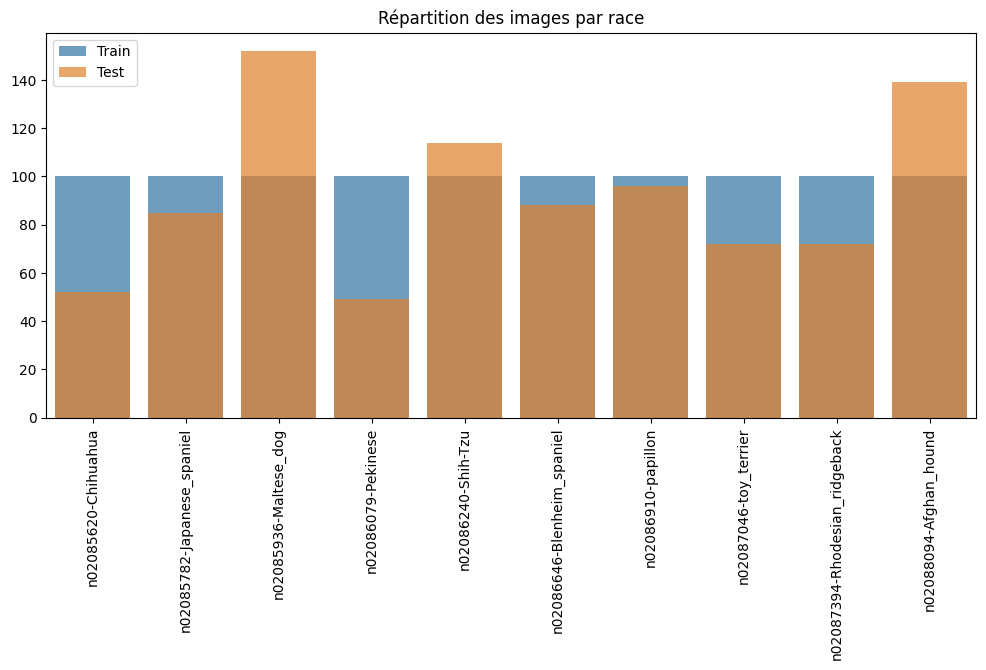

In [7]:
train_counts = {cls: sum(y_train == cls) for cls in np.unique(y_train)}
test_counts = {cls: sum(y_test == cls) for cls in np.unique(y_test)}
plt.figure(figsize=(12, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), alpha=0.7, label="Train")
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), alpha=0.7, label="Test")
plt.xticks(rotation=90)
plt.legend()
plt.title("Répartition des images par race")
plt.show()

Chaque race de chien dispose de 100 images dans le train, on peut donc faire nos modeles sans se soucier d'un eventuel desequilibre

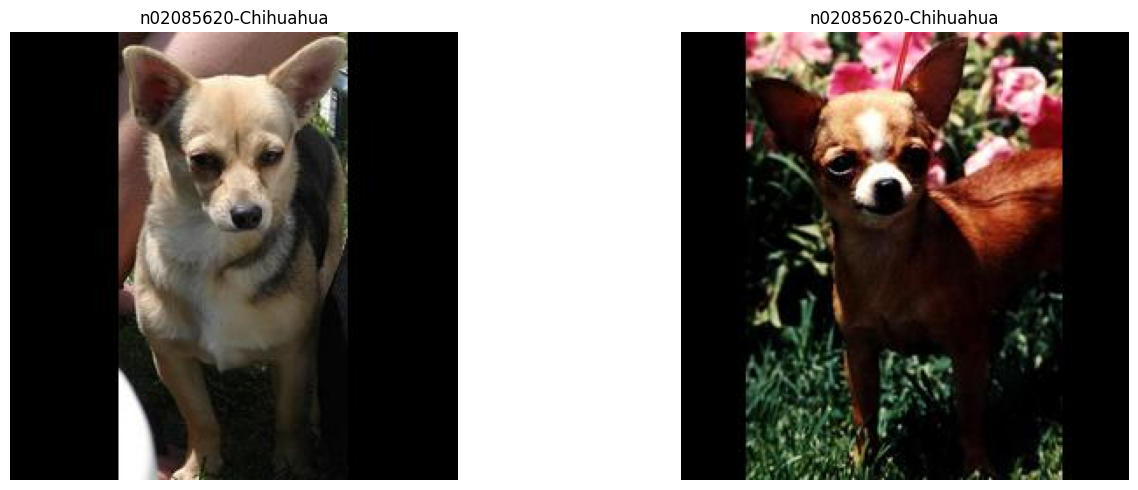

In [25]:
df_imgs=image_search.index_dataset(images_dir)
image_search.show_images(df_imgs,max_images=2)

### 3. Encodage des labels

In [8]:
# Conversion des labels en int
# LabelEncoder assigne un numéro unique à chaque classe
label_encoder = sklearn.preprocessing.LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Transformation des labels entiers en représentation one-hot
# Nécessaire pour  softmax en sortie
# Format one-hot : [1, 0, 0] = classe 0, [0, 1, 0] = classe 1, etc.

y_train_cat = tf.keras.utils.to_categorical(y_train_int)
y_test_cat = tf.keras.utils.to_categorical(y_test_int)


In [9]:
print(f"y_train_int: {y_train_int[:10]}")  
print(f"y_train_cat shape: {y_train_cat.shape} \n \n")  
print(f"class 0 : {y_train_cat[0]}")

y_train_int: [0 0 0 0 0 0 0 0 0 0]
y_train_cat shape: (1000, 10) 
 

class 0 : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Normalisation des pixels entre 0 et 1

In [10]:
X_train = X_train / 255
X_test = X_test / 255


In [22]:

model = tf.keras.models.Sequential([
    layers.Flatten(input_shape=X_train.shape[1:]),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])


Couche Flatten : aplatie chaque image d'entrée 3D en un vecteur 1D


In [23]:

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Optimiseur : adam
    # - Il ajuste automatiquement le taux d'apprentissage pendant l'entraînement.
# Fonction de perte : categorical_crossentropy
    # - Compare la distribution prédite (softmax) à la distribution réelle (one-hot)


In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,174,858 (96.03 MB)

 Trainable params: 25,174,858 (96.03 MB)

 Non-trainable params: 0 (0.00 B)

La perte categorical_crossentropy mesure l'écart entre les prédictions et les vraies classes


In [33]:
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=45,
    validation_data=(X_test, y_test_cat)
)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - accuracy: 0.4952 - loss: 1.9343 - val_accuracy: 0.2579 - val_loss: 3.1912
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.5908 - loss: 1.4527 - val_accuracy: 0.1806 - val_loss: 4.5790
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.6219 - loss: 1.1601 - val_accuracy: 0.2155 - val_loss: 4.0171
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.6484 - loss: 1.0668 - val_accuracy: 0.1926 - val_loss: 4.3899
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.5638 - loss: 1.5056 - val_accuracy: 0.2535 - val_loss: 4.1890
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.6440 - loss: 1.1160 - val_accuracy: 0.1850 - val_loss: 3.5419
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - accuracy: 0.7661 - loss: 0.6659 - val_accuracy: 0.2677 - val_loss: 4.1632
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.7059 - loss: 0.7812 - val_accuracy: 0.

Une époque  représente un passage complet sur l’ensemble des données d’entraînement.
Un batch est un sous-ensemble des données utilisé pour ajuster les poids du modèle. Plutôt que de traiter toutes les images en une seule fois, elles sont divisées en lots d'images, ce qui accélère l’entraînement et stabilise la descente de gradient.  

L'évaluation sur les données de validation  sert à vérifier si le modèle fonctionne bien sur des images qu’il n’a jamais vues pendant l’entraînement.


>Surapprentisage

Le modèle semble bien apprendre sur les données d’entraînement atteignant une précision de 99.72% à l’époque 29. Cependant, la précision sur les données de validation reste très faible, autour de 26.55%, et la perte de validation reste élevée (3.66).
Cela indique un surapprentissage : le modèle mémorise trop bien les données d’entraînement mais ne parvient pas à généraliser sur des images qu’il n’a jamais vues. Une possible solution serait de réduire la complexité du modèle, ajouter de la régularisation (comme Dropout), ou augmenter la taille du jeu de données pour améliorer la généralisation.


In [ ]:
#  pour éviter le surapprentissage
model = tf.keras.models.Sequential([
    layers.Flatten(input_shape=X_train.shape[1:]),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),  # Ajout de Dropout pour réduire le surapprentissage
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(
    X_train, y_train_cat,
    epochs=40,
    batch_size=90,  
    validation_data=(X_test, y_test_cat)
)

Epoch 1/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - accuracy: 0.1160 - loss: 22.5872 - val_accuracy: 0.1240 - val_loss: 2.3076
Epoch 2/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.1142 - loss: 2.3125 - val_accuracy: 0.1230 - val_loss: 2.3033
Epoch 3/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.0868 - loss: 2.3029 - val_accuracy: 0.1240 - val_loss: 2.3034
Epoch 4/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.0827 - loss: 2.3071 - val_accuracy: 0.1240 - val_loss: 2.3030
Epoch 5/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.1070 - loss: 2.3026 - val_accuracy: 0.1240 - val_loss: 2.3031
Epoch 6/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.1060 - loss: 2.3025 - val_accuracy: 0.1240 - val_loss: 2.3032
Epoch 7/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.1012 - loss: 2.3029 - val_accuracy: 0.1240 - val_loss: 2.3034
Epoch 8/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - accuracy: 0.1038 - loss: 2.3025 - val_accuracy: 0

Le Dropout est une technique utilisée pour réduire le surapprentissage en empêchant le modèle de trop mémoriser les données d’entraînement. À chaque étape de l’apprentissage, il désactive aléatoirement un certain pourcentage de neurones, forçant le modèle à apprendre des représentations plus générales plutôt que de dépendre de certaines connexions spécifiques.  

Cela améliore la capacité de généralisation du modèle, le rendant plus performant sur des données qu’il n’a jamais vues.

### Amélioration de la généralisation : approche avec régularisation et ajustement du taux d'apprentissage



In [25]:

model = tf.keras.models.Sequential([
    layers.Flatten(input_shape=X_train.shape[1:]),
    
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │   201,327,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,993,482 (770.54 MB)

 Trainable params: 201,989,898 (770.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

#### Formation du modéle 

La première couche Flatten(input_shape=...) 

On utilise ensuite trois couches Dense, avec respectivement 1024, 512 et 256 neurones. Le choix de ces tailles reflète une approche : plus on avance dans le réseau, plus on se rapproche d'une représentation compacte  de l'information.

Chaque couche dense est suivie d’une fonction d’activation ReLU qui introduit la non-linéarité nécessaire à l’apprentissage de relations complexes.

La régularisation L2  ajoute une pénalisation sur les poids trop grands afin de limiter le surapprentissage. Plus ce coefficient est élevé, plus le modèle est encouragé à rester simple.

Puis vient une BatchNormalization. Cette couche recentre et réduit automatiquement les activations intermédiaires. Cela a deux effets : accélérer la convergence de l'entraînement, et rendre l'entraînement plus stable.

Ensuite, on applique un Dropout, une forme de régularisation stochastique qui désactive aléatoirement un certain pourcentage des neurones à chaque passage. Cela évite que le réseau devienne trop dépendant d'un petit nombre de neurones.

Enfin, la dernière couche Dense(num_classes, activation='softmax') est la couche de sortie. Elle a autant de neurones que de classes, ici 10, et applique la fonction softmax pour transformer les scores en probabilités. Chaque sortie représente la probabilité d'appartenance à une classe.

#### Entrainement du modéle

L’optimiseur Adam est un choix standard qui combine à la fois la descente de gradient stochastique et des méthodes adaptatives pour ajuster le taux d’apprentissage. La fonction de perte est categorical_crossentropy, qui est bien adaptée ici car les labels ont été transformés en vecteurs one-hot. On suit la métrique de précision (accuracy) pour évaluer les performances.
L'entraînement est ensuite lancé avec un ReduceLROnPlateau :Ce callback permet de réduire automatiquement le taux d’apprentissage si la perte de validation ne s’améliore pas pendant 4 epochs consécutives. Le taux est réduit d’un facteur de 0.3 à chaque fois, jusqu’à un minimum de 0.00001. Cela permet d’affiner l’optimisation quand le modèle commence à stagner.

In [26]:
# Scheduler pour ajuster dynamiquement le taux d'apprentissage
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=4, min_lr=1e-5, verbose=1
)

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    callbacks=[reduce_lr],
    verbose=2
)


Epoch 1/50
16/16 - 47s - 3s/step - accuracy: 0.1620 - loss: 8.1754 - val_accuracy: 0.1719 - val_loss: 23.8019 - learning_rate: 1.0000e-03
Epoch 2/50
16/16 - 36s - 2s/step - accuracy: 0.2220 - loss: 10.5027 - val_accuracy: 0.1687 - val_loss: 21.8355 - learning_rate: 1.0000e-03
Epoch 3/50
16/16 - 35s - 2s/step - accuracy: 0.2430 - loss: 10.5458 - val_accuracy: 0.1806 - val_loss: 14.0682 - learning_rate: 1.0000e-03
Epoch 4/50
16/16 - 34s - 2s/step - accuracy: 0.2550 - loss: 9.9621 - val_accuracy: 0.2089 - val_loss: 12.8357 - learning_rate: 1.0000e-03
Epoch 5/50
16/16 - 34s - 2s/step - accuracy: 0.2910 - loss: 9.1790 - val_accuracy: 0.1578 - val_loss: 11.1714 - learning_rate: 1.0000e-03
Epoch 6/50
16/16 - 33s - 2s/step - accuracy: 0.3100 - loss: 8.5392 - val_accuracy: 0.2144 - val_loss: 9.7783 - learning_rate: 1.0000e-03
Epoch 7/50
16/16 - 34s - 2s/step - accuracy: 0.3580 - loss: 7.9157 - val_accuracy: 0.1904 - val_loss: 8.9423 - learning_rate: 1.0000e-03
Epoch 8/50
16/16 - 36s - 2s/step -

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc:.2%}")


29/29 - 8s - 275ms/step - accuracy: 0.3079 - loss: 4.3160
Test accuracy: 30.79%


In [28]:
# Prédictions du modèle
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes
y_true_classes = np.argmax(y_test_cat, axis=1)  # Convertir les labels one-hot en classes

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step


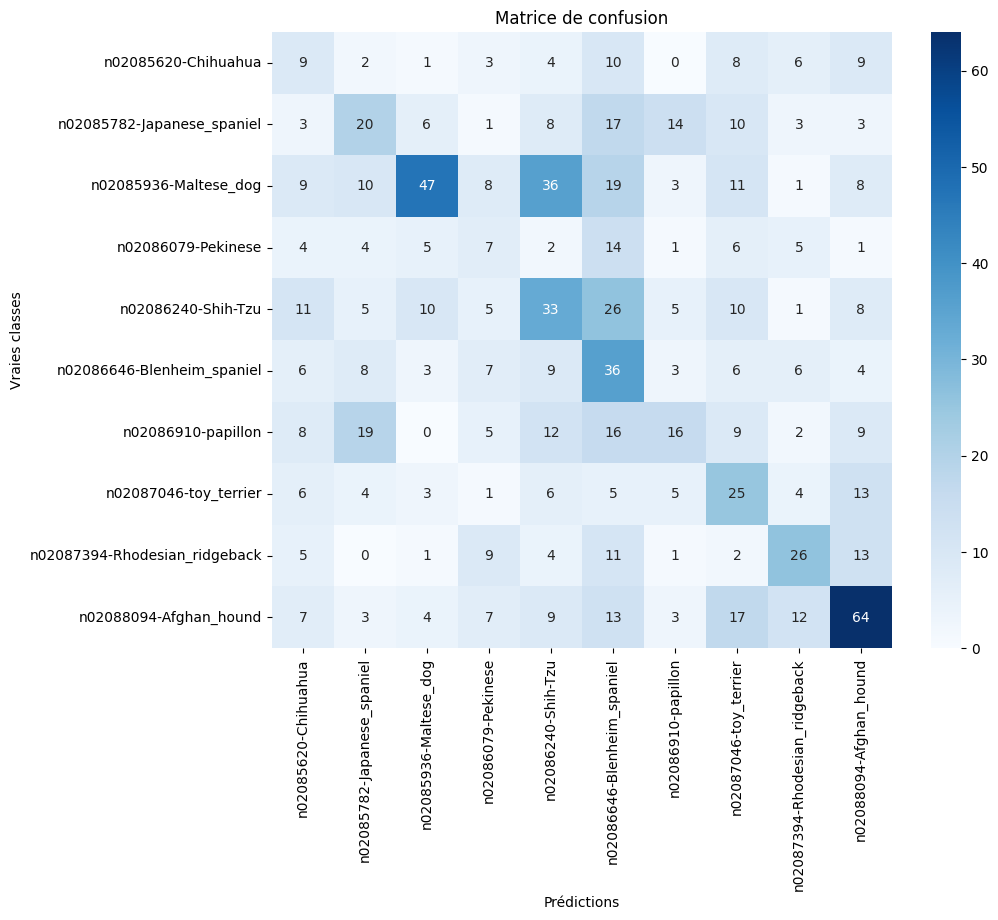

In [29]:

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()

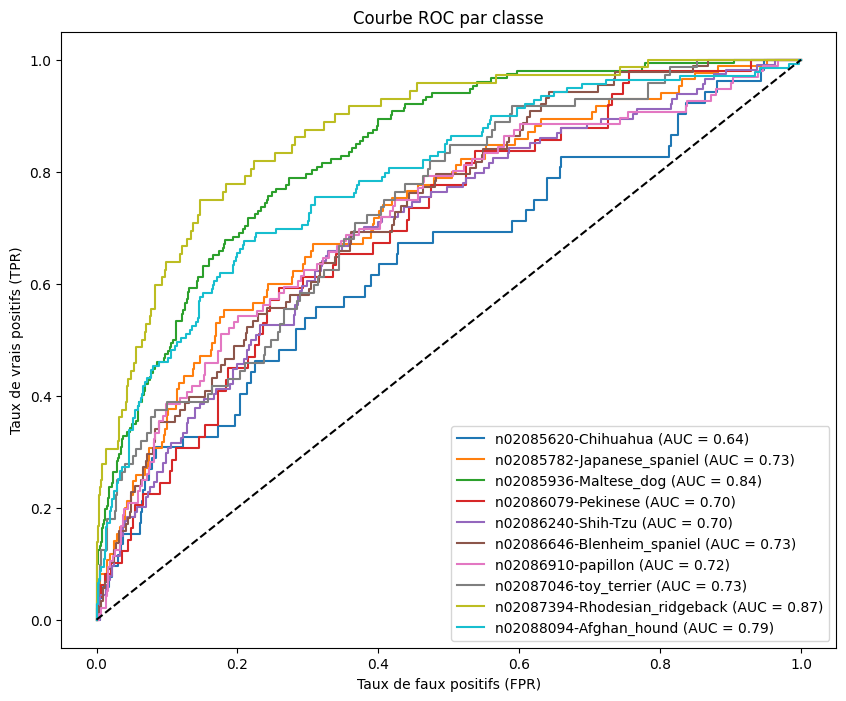

In [30]:
#Courbe de ROC
plt.figure(figsize=(10, 8))
for i in range(y_test_cat.shape[1]):  # Pour chaque classe
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Ligne de référence
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC par classe")
plt.legend()
plt.show()

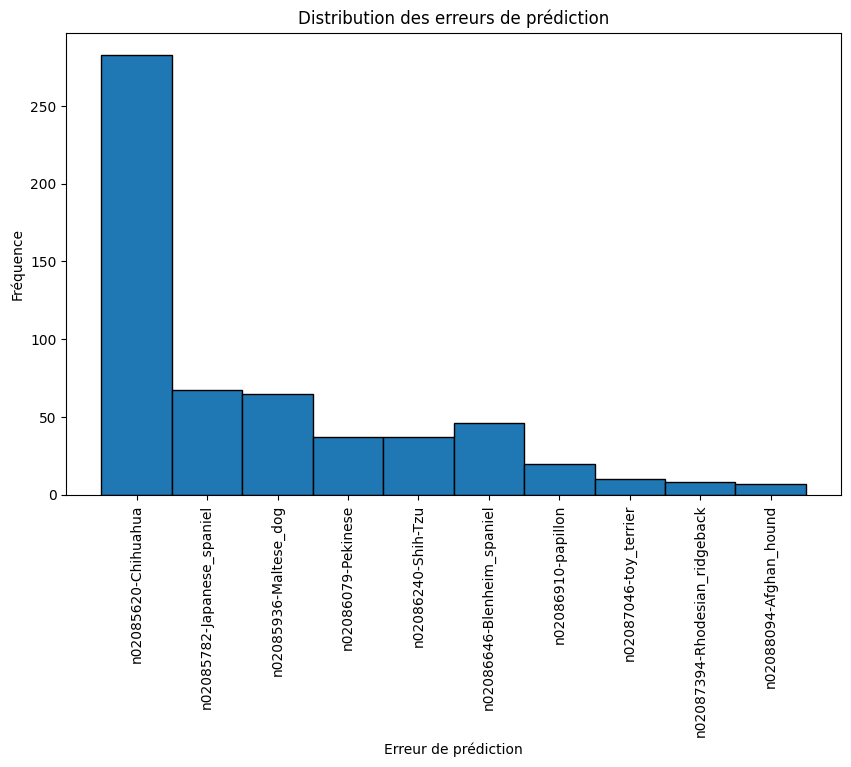

In [31]:
# Histogramme des erreurs de prediction
errors = y_true_classes - y_pred_classes  # Différence entre vraies classes et prédictions

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=np.arange(-0.5, y_test_cat.shape[1] + 0.5, 1), edgecolor='black')
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs de prédiction")
plt.xticks(range(y_test_cat.shape[1]), label_encoder.classes_, rotation=90) 
plt.show()

C'est mieux que ce que j'attendais,par contre le modéle a du mal avec les Chihawa, il les classes systematiquement mal. Nous allons acorder une attention particuliére à cette race

### Conclusion MLP

Lorsqu'on choisis un réseau de neurones entièrement connecté dense pour de la classification d'images, on fais le pari que les pixels, pris individuellement et sans structure spatiale explicite, suffisent à différencier les classes. Ce pari peut marcher sur des images simples, mais reste limité surtout dans le cas de la classification fine.

Après 50 époques d'entraînement, le modèle   a atteint une précision de 90,8 % sur l’ensemble d'entraînement, mais seulement 30,8 % sur l’ensemble de validation. Ce décalage massif entre la performance sur les données vues  et les données non vues  est un signe d'overfitting mais c'est bien moins grave que le modéle initiale.

Ce comportement est typique des réseaux denses appliqués à des données d'images :
un MLP, même bien régularisé, ne sait pas exploiter la structure spatiale (formes, textures, voisinage local des pixels). Il compense alors en mémorisant les images d'entraînement au lieu de généraliser.

Ce résultat montre que malgré toutes les techniques de régularisation utilisées (Dropout, L2, BatchNorm, ReduceLROnPlateau), un réseau dense n'est pas adapté à des images complexes. Il manque l’intelligence locale des CNNs, qui savent apprendre progressivement des motifs (bords, textures, objets) en exploitant les relations spatiales entre pixels.

## Un réseau de neurone CNN

ref :[Tutoriel Tensorflow](https://www.tensorflow.org/tutorials/images/cnn?hl=fr)

Passons maintenant à un réseau de neurones convolutif, qui est plus naturel pour l’analyse d’images. Contrairement à un MLP, un CNN exploite la structure spatiale locale de l’image pour apprendre des motifs (bords, textures, objets) avec moins de paramètres.

### Un CNN basique

On commence par initialiser un modèle séquentiel, où les couches s’enchaînent de manière linéaire

In [37]:
model = tf.keras.models.Sequential()

In [38]:
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]))

La première couche est une convolution 2D. Elle applique 32 filtres de taille 3×3 sur l’image d’entrée. Cela permet d’extraire des motifs locaux comme des contours. La fonction d’activation ReLU introduit de la non-linéarité.

In [39]:
model.add(layers.MaxPooling2D((2, 2)))


Un max-pooling réduit la taille des cartes d’activation en prenant le maximum de chaque bloc 2×2. Cela permet de réduire la complexité tout en conservant les caractéristiques importantes.

In [40]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


On ajoute une deuxième couche de convolution, cette fois avec 64 filtres, suivie d’un deuxième pooling. Le modèle apprend ainsi des motifs plus complexes à mesure que la profondeur augmente.
On applique du Dropout à 50 % pour éviter le surapprentissage. Puis on passe à une couche dense de 128 neurones avec ReLU.

In [ ]:
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Flatten())


La dernière couche convolutive extrait des caractéristiques , que l’on aplatit ensuite en un vecteur avec Flatten().

In [42]:
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128, activation='relu'))

On applique du Dropout à 50 % pour éviter le surapprentissage. Puis on passe à une couche dense de 128 neurones avec ReLU.

In [43]:
model.add(layers.Dense(10, activation='softmax'))
# Couche de sortie

In [45]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 62, 62, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 62, 62, 128)    │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 62, 62, 10)     │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,514 (177.79 KB)

 Trainable params: 45,514 (177.79 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    validation_data=(X_test, y_test_cat)
)

MemoryError: Unable to allocate 750. MiB for an array with shape (1000, 256, 256, 3) and data type float32